In [1]:
'''
MINI GPT Test
20250703 Ryan
'''

'\nMINI GPT Test\n20250703 Ryan\n'

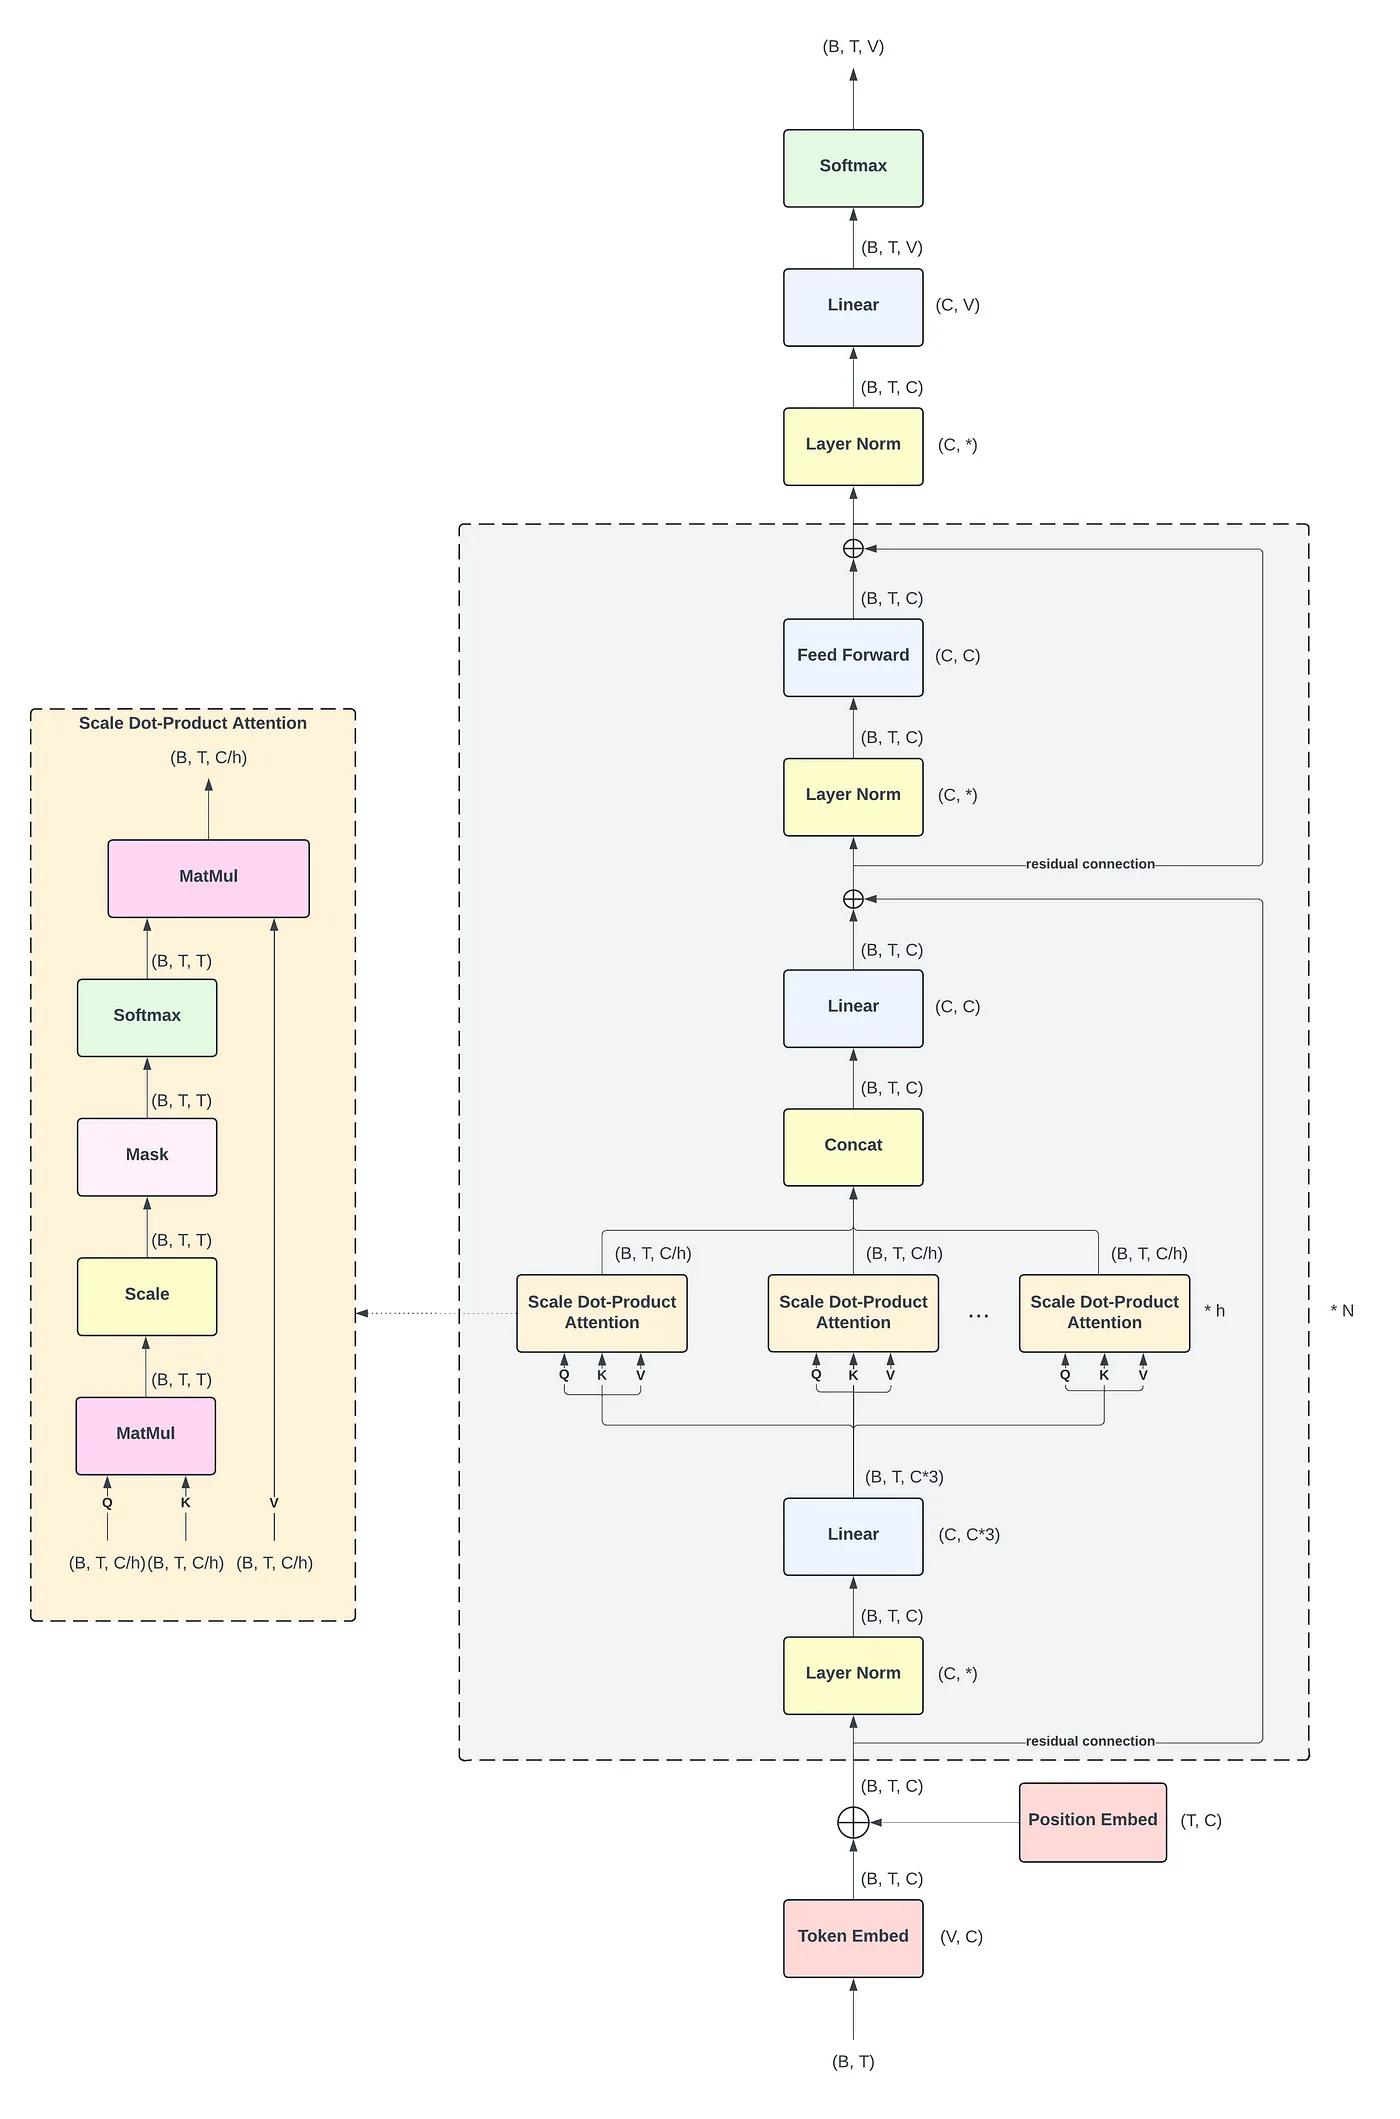

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from dataclasses import dataclass
import math

torch.manual_seed(1024)

In [15]:
#初始化模型配置
@dataclass
class GPTConfig:
    block_size : int = 512 #文本最大长度 相当于max_seq_len
    batch_size : int = 12
    n_layer : int = 6
    n_head : int = 12
    n_embd : int =768  #hidden dim 
    head_size : int = n_embd // n_head
    dropout : float = 0.1
    vocab_size : int = 50257

In [33]:
#单头注意力机制
class SingleHeadAttention(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.key = nn.Linear(config.n_embd,config.head_size)
        self.query = nn.Linear(config.n_embd,config.head_size)
        self.value = nn.Linear(config.n_embd,config.head_size)
        self.head_size = config.head_size

        #需要attention_mask

        self.register_buffer(
            'attention_mask',
            torch.tril(
                torch.ones(config.block_size,config.block_size)
            )
        )
        self.drop_out = nn.Dropout(config.dropout)

    def forward(self,x):
        batch_size,seq_len,hidden_size = x.size()
        k = self.key(x)
        v = self.value(x)
        q = self.query(x)

        weight = q @ k.transpose(-2,-1)

        #在进入softmax之前进行缩放 并进行mask
        weight = weight.masked_fill(
            self.attention_mask[:seq_len,:seq_len] == 0,
            float('-inf')
        )/math.sqrt(self.head_size)

        weight = F.softmax(weight,dim = -1)
        weight = self.drop_out(weight)
        out = weight @ v
        return out
    

In [34]:
# 多头注意力机制 合并多个单头
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.heads = nn.ModuleList(
            [
                SingleHeadAttention(config)
                for _ in range(config.n_head)
            ]
        )
        self.proj = nn.Linear(config.n_embd,config.n_embd)
        self.dropout = nn.Dropout(config.dropout)



    def forward(self,x):
        output = torch.cat(
            [h(x) for h in self.heads],
            dim=-1
        )
        output = self.proj(output)
        output = self.dropout(output)

        return output

In [35]:
#feed forward 层
class FeedForward(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd,4*config.n_embd),
            nn.GELU(),
            nn.Linear(4*config.n_embd,config.n_embd),
            nn.Dropout(config.dropout)
        )


    def forward(self,x):
        return self.net(x)

In [36]:
#完整的Block
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
    
        head_size = config.n_embd // config.n_head
        self.att = MultiHeadAttention(config)
        self.ffn = FeedForward(config)
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
    
    def forward(self,x):
        x = x + self.att(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

In [47]:
#完整的GPT structure

class GPT(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.token_embedding_table = nn.Embedding(config.vocab_size,config.n_embd)
        self.position_embedding_table = nn.Embedding(config.block_size,config.n_embd)
        self.blocks = nn.Sequential(
            *[Block(config) for _ in range(config.n_layer)]
        )
        self.ln_final = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd,config.vocab_size,bias = False)
        self.block_size = config.block_size
        # 共享参数 tied weight
        # self.token_embedding_table.weight = self.lm_head.weight   

        self.apply(self._init_weights)
    
    def _init_weights(self,module):
        if isinstance(module, nn.Linear):
            # 这里使用的是正态分布初始化
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, idx, targets=None):
        # idx 是输入的 token ids
        #targets 是错位的句子 是idx 的下一个词
        # idx = tokens[:-1]     # [1, 23, 45]
        # targets = tokens[1:]  # [23, 45, 67]

        batch, seq_len = idx.size()
        token_emb = self.token_embedding_table(idx)

        # seq 长度是这次输入的最大长度
        pos_emb = self.position_embedding_table(
            # 要确保 位置编码和输入的 idx 在同一个设备上
            torch.arange(seq_len, device=idx.device)
        )
        x = token_emb + pos_emb   # shape is (batch, seq_len, n_embd)
        x = self.blocks(x)
        x = self.ln_final(x)
        logits = self.lm_head(x)   # shape is (batch, seq_len, vocab_size)
        
        if targets is None:
            loss = None
        else:
            batch, seq_len, vocab_size = logits.size()
            logits = logits.view(batch * seq_len, vocab_size)
            targets = targets.view(batch * seq_len)
            loss = F.cross_entropy(logits, targets)
        return logits, loss
    

    def generate(self,idx,max_new_tokens):
        for _ in range(max_new_tokens):
            #如果序列太长，只取后block_size长度的序列做生成
            idx_cond = idx if idx.size(1) <= self.block_size else idx[:,-self.block_size:]
            #获取预测
            logits,_ = self(idx_cond)
            #只关注最后一个时间步的预测
            logits = logits[:,-1,:]
            
            probs = F.softmax(logits,dim=-1)
            #采样下一个token
            idx_next = torch.multinomial(probs,num_samples=1) #(B,1)
            #附加到序列上
            idx = torch.cat((idx,idx_next),dim=1) #(B,T+1)

            return idx
    

In [48]:
model = GPT(GPTConfig())
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params / 1e6} M") 

Total parameters: 120.116736 M


In [39]:
from datasets import load_dataset

data = load_dataset('LazyAGI/Chinese_Classics_Articles',split='train')
data

Using the latest cached version of the dataset since LazyAGI/Chinese_Classics_Articles couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/ryan.pang/.cache/huggingface/datasets/LazyAGI___chinese_classics_articles/default/0.0.0/98cdf222d063b5718641d9ccfd094244ac6bc4fc (last modified on Thu Jul  3 16:24:31 2025).


Dataset({
    features: ['text'],
    num_rows: 355
})

In [56]:
data['text'][:5]

['天命之谓性，率性之谓道，修道之谓教。',
 '道也者，不可须臾（yú）离也；可离，非道也。是故君子戒慎乎其所不睹，恐惧乎其所不闻。莫见（xian）乎隐，莫显乎微，故君子慎其独也。',
 '喜怒哀乐之未发，谓之中；发而皆中节，谓之和。中也者，天下之大本也；和也者，天下之达道也。致中和，天地位焉，万物育焉。',
 '',
 '仲尼曰：“君子中庸，小人反中庸。君子之中庸也，君子而时中；小人之反中庸也，小人而无忌惮也。”']

In [40]:
import tiktoken
import json
class GPTTextDataset(Dataset):
    def __init__(self, dataset, block_size=512, max_samples=1000):
        self.enc = tiktoken.get_encoding("gpt2")
        self.block_size = block_size
        self.eos_token = self.enc.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]

        self.encoded_data = []
        full_encoded = []

        for i, item in enumerate(dataset):
            if i >= max_samples:
                break
            text = item["text"]
            ids = self.enc.encode(text)
            full_encoded.extend(ids + [self.eos_token])

        # 切块
        for i in range(0, len(full_encoded), block_size):
            chunk = full_encoded[i:i + block_size + 1]
            if len(chunk) < block_size + 1:
                chunk += [self.eos_token] * (block_size + 1 - len(chunk))
            self.encoded_data.append(chunk)

    def __len__(self):
        return len(self.encoded_data)

    def __getitem__(self, idx):
        chunk = self.encoded_data[idx]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y



In [41]:
train_dataset = GPTTextDataset(data)
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [0.9, 0.1])
train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=12, shuffle=False)

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
# 设置 cosine 学习率
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1000)

In [50]:
# 训练循环
def train(model, optimizer, scheduler, train_loader, val_loader, device):
    model.train()
    total_loss = 0
    for batch_idx, (x, y) in enumerate(train_loader):
        # 将数据移到设备上
        x, y = x.to(device), y.to(device)
        
        # 前向传播
        logits, loss = model(x, targets=y)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # 调整学习率
        scheduler.step()
        
        total_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item():.4f}')
    return total_loss

def eval(model, val_loader, device):
    # 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits, loss = model(x, targets=y)
            val_loss += loss.item()
    return val_loss


for epoch in range(2):
    train_loss = train(model, optimizer, scheduler, train_loader, val_loader, device)
    val_loss = eval(model, val_loader, device)
    print(f'Epoch: {epoch}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}')

    # 保存模型
    avg_val_loss = val_loss / len(val_loader)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_loss': avg_val_loss,
    }
    # # 保存每个epoch的模型
    # torch.save(checkpoint, f'checkpoints/model_epoch_{epoch}.pt')

Epoch: 0, Batch: 0, Loss: 10.9594
Epoch: 0, Train Loss: 10.9612, Val Loss: 10.9461
Epoch: 1, Batch: 0, Loss: 10.9453
Epoch: 1, Train Loss: 10.9587, Val Loss: 10.9461


In [57]:
enc = tiktoken.get_encoding("gpt2")
prompt = "我喜欢学习大模型"
idx = torch.tensor([enc.encode(prompt)], dtype=torch.long).to(device)

model.eval()
with torch.no_grad():
    out = model.generate(idx, max_new_tokens=50)

print(enc.decode(out[0].tolist()))


我喜欢学习大模型kie
